# Fooling LIME and SHAP — Heart Disease Dataset

Reproducción del framework adversarial de Slack et al. (2020) aplicado al dataset de enfermedades cardíacas (UCI).

**Estructura:**
1. Instalación y carga de datos
2. Exploración y preprocesamiento
3. Clasificador sesgado `f` (usa solo `sex`)
4. Clasificador inocuo `ψ`
5. OOD Classifier
6. Scaffolded classifier `e`
7. Evaluación del ataque sobre LIME
8. Evaluación del ataque sobre SHAP
9. Análisis de resultados y visualización

## 0. Instalación de dependencias

In [ ]:
# !pip install lime shap scikit-learn pandas numpy matplotlib seaborn ucimlrepo -q

## 1. Carga de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

# Heart Disease dataset (ID=45 en UCI)
heart_disease = fetch_ucirepo(id=45)
X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets

print("Shape X:", X_raw.shape)
print("Columnas:", X_raw.columns.tolist())
print("\nPrimeras filas:")
X_raw.head()

len(X_raw), len(y_raw)

Shape X: (303, 13)
Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Primeras filas:


(303, 303)

## 2. Exploración y preprocesamiento

**Atributo sensible**: `sex` (0=female, 1=male) — 68% son hombres en este dataset.

**Target**: enfermedad cardíaca presente (0=ausente, 1=presente). El dataset original tiene valores 0-4; binarizamos en 0 vs >0.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Binarizar target: 0=no enfermedad, 1=enfermedad
y = (y_raw.values.ravel() > 0).astype(int)

# Eliminar filas con NaN
df = X_raw.copy()
df['target'] = y
df = df.dropna().reset_index(drop=True)

X = df.drop('target', axis=1)
y = df['target'].values

feature_names = X.columns.tolist()
sensitive_feature = 'sex'
sensitive_idx = feature_names.index(sensitive_feature)

print(f"Dataset limpio: {X.shape}")
print(f"Distribución target: {pd.Series(y).value_counts().to_dict()}")
print(f"Distribución sexo: {X['sex'].value_counts().to_dict()} (0=F, 1=M)")

Dataset limpio: (297, 13)
Distribución target: {0: 160, 1: 137}
Distribución sexo: {1: 201, 0: 96} (0=F, 1=M)


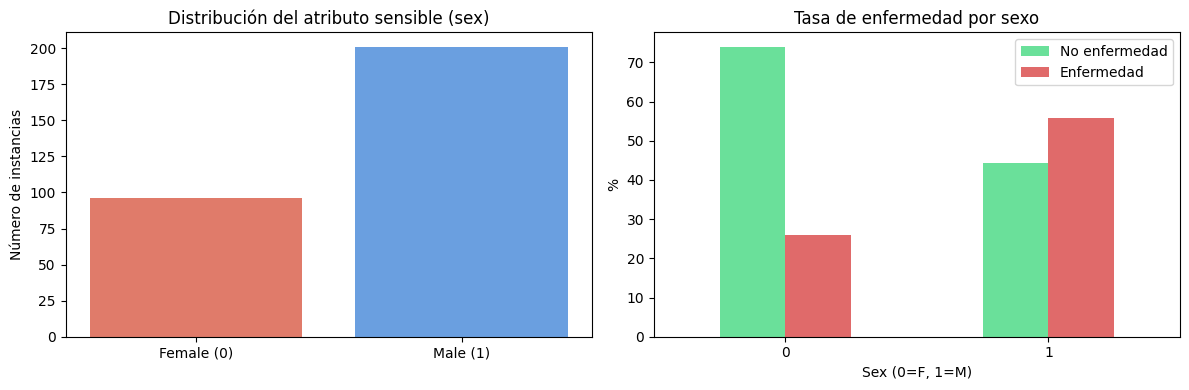

In [5]:
# Visualización del atributo sensible vs target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de sexo
axes[0].bar(['Female (0)', 'Male (1)'],
            X['sex'].value_counts().sort_index().values,
            color=['#E07B6A', '#6A9FE0'])
axes[0].set_title('Distribución del atributo sensible (sex)')
axes[0].set_ylabel('Número de instancias')

# Correlación sexo-target
ct = pd.crosstab(X['sex'], y, normalize='index') * 100
ct.plot(kind='bar', ax=axes[1], color=['#6AE09A', '#E06A6A'])
axes[1].set_title('Tasa de enfermedad por sexo')
axes[1].set_xlabel('Sex (0=F, 1=M)')
axes[1].set_ylabel('%')
axes[1].legend(['No enfermedad', 'Enfermedad'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [6]:
# Split train/test (90/10 como en el paper)
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.1, random_state=42, stratify=y
)

# Escalar (útil para ψ y el OOD classifier)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (267, 13) | Test: (30, 13)


## 3. Clasificador sesgado `f`

Discrimina **únicamente** en base al sexo del paciente.
Si `sex == 1` (male) → predice enfermedad (1), si no → predice 0.

Demographic parity ratio = 0: la predicción depende 100% de un atributo protegido.

In [7]:
def f_biased(X_input):
    """Clasificador sesgado: predice basándose solo en 'sex' (col index 1)."""
    if isinstance(X_input, pd.DataFrame):
        return (X_input['sex'].values == 1).astype(int)
    return (X_input[:, sensitive_idx] == 1).astype(int)

# Verificar fidelidad en test
preds_f = f_biased(X_test)
print(f"Predicciones de f en test: {np.unique(preds_f, return_counts=True)}")
print(f"Accuracy de f (vs y real): {np.mean(preds_f == y_test):.3f}")
print("Nota: accuracy alta no implica ausencia de sesgo — f ignora todos los síntomas clínicos")

Predicciones de f en test: (array([0, 1]), array([ 9, 21]))
Accuracy de f (vs y real): 0.767
Nota: accuracy alta no implica ausencia de sesgo — f ignora todos los síntomas clínicos


## 4. Clasificador inocuo `ψ`

Usa una **feature sintética no correlacionada** con el sexo del paciente.
Esto es lo que LIME y SHAP verán como el feature importante tras el ataque.

In [8]:
np.random.seed(42)

# Generar feature sintética para train y test (binaria, no correlacionada con sex)
uncorrelated_train = np.random.randint(0, 2, size=len(X_train))
uncorrelated_test = np.random.randint(0, 2, size=len(X_test))

# Verificar correlación con atributo sensible
corr = np.corrcoef(X_train[:, sensitive_idx], uncorrelated_train)[0, 1]
print(f"Correlación entre 'sex' y feature sintética: {corr:.4f} (debe ser ~0)")

def psi_unbiased(X_input, uncorrelated_feature):
    """Clasificador inocuo: predice basándose solo en la feature sintética."""
    return uncorrelated_feature.astype(int)

# Añadir la feature sintética al dataset para que LIME/SHAP la vean
feature_names_ext = feature_names + ['uncorrelated_feature_1']
X_train_ext = np.column_stack([X_train, uncorrelated_train])
X_test_ext = np.column_stack([X_test, uncorrelated_test])

print(f"\nShape con feature extendida: train={X_train_ext.shape}, test={X_test_ext.shape}")

Correlación entre 'sex' y feature sintética: 0.0429 (debe ser ~0)

Shape con feature extendida: train=(267, 14), test=(30, 14)


## 5. OOD Classifier

Detecta si una instancia viene de la distribución real o es una perturbación sintética (como las que genera LIME/SHAP).

**Proceso:**
1. Generar perturbaciones estilo LIME (ruido gaussiano N(0,1))
2. Etiquetar: datos reales → 0, perturbaciones → 1
3. Entrenar un Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.decomposition import PCA

def generate_lime_perturbations(X_real, n_perturbations=None):
    """Genera perturbaciones estilo LIME: ruido gaussiano N(0,1) sobre cada feature."""
    if n_perturbations is None:
        n_perturbations = len(X_real)
    noise = np.random.normal(0, 1, (n_perturbations, X_real.shape[1]))
    # Seleccionar instancias base aleatoriamente
    base_idx = np.random.choice(len(X_real), n_perturbations)
    return X_real[base_idx] + noise

# Generar perturbaciones sobre el training set extendido
X_perturbed = generate_lime_perturbations(X_train_ext)

# Combinar real + perturbado
X_ood_train = np.vstack([X_train_ext, X_perturbed])
y_ood_train = np.array([0] * len(X_train_ext) + [1] * len(X_perturbed))

# Entrenar OOD classifier
ood_clf = RandomForestClassifier(n_estimators=100, random_state=42)
ood_clf.fit(X_ood_train, y_ood_train)

# Evaluar en datos de test
X_perturbed_test = generate_lime_perturbations(X_test_ext)
X_ood_test = np.vstack([X_test_ext, X_perturbed_test])
y_ood_test = np.array([0] * len(X_test_ext) + [1] * len(X_perturbed_test))

y_ood_pred = ood_clf.predict(X_ood_test)
f1 = f1_score(y_ood_test, y_ood_pred)
print(f"OOD Classifier F1 score: {f1:.4f}")
print(classification_report(y_ood_test, y_ood_pred, target_names=['Real', 'Perturbado']))

OOD Classifier F1 score: 1.0000
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00        30
  Perturbado       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



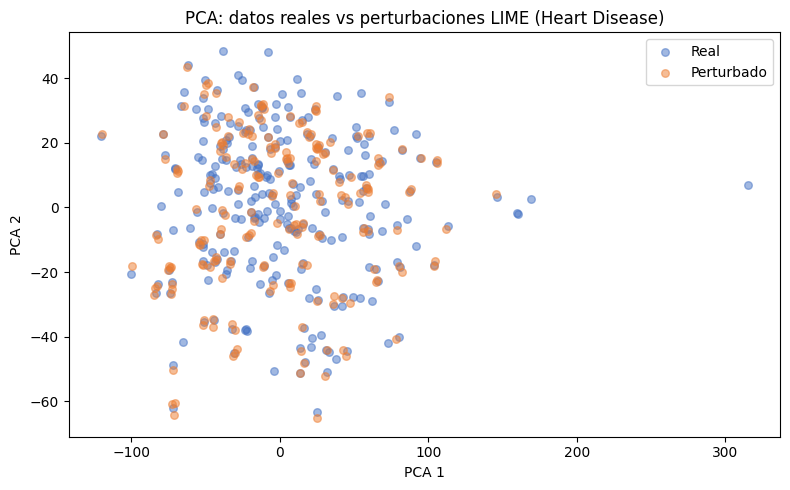

→ Si las nubes están separadas, el OOD classifier tendrá alta capacidad de distinción


In [10]:
# Visualización PCA — replica la Figura 1 del paper
pca = PCA(n_components=2)
combined = np.vstack([X_train_ext, X_perturbed[:200]])
labels_pca = ['Real'] * len(X_train_ext) + ['Perturbado'] * 200
reduced = pca.fit_transform(combined)

plt.figure(figsize=(8, 5))
colors = {'Real': '#4472C4', 'Perturbado': '#ED7D31'}
for label in ['Real', 'Perturbado']:
    mask = np.array(labels_pca) == label
    plt.scatter(reduced[mask, 0], reduced[mask, 1],
                c=colors[label], label=label, alpha=0.5, s=30)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA: datos reales vs perturbaciones LIME (Heart Disease)')
plt.legend()
plt.tight_layout()
plt.show()
print("→ Si las nubes están separadas, el OOD classifier tendrá alta capacidad de distinción")

## 6. Scaffolded Classifier `e`

El clasificador adversarial que combina `f` y `ψ` usando el OOD classifier.

In [11]:
class AdversarialClassifier:
    """
    Scaffolded classifier e(x):
      - Si x parece real → usa f (clasificador sesgado)
      - Si x parece perturbado → usa ψ (clasificador inocuo)
    """
    def __init__(self, ood_clf, f_biased_fn, threshold=0.5):
        self.ood_clf = ood_clf
        self.f_biased_fn = f_biased_fn
        self.threshold = threshold

    def predict(self, X_input):
        if X_input.ndim == 1:
            X_input = X_input.reshape(1, -1)

        predictions = np.zeros(len(X_input), dtype=int)
        ood_proba = self.ood_clf.predict_proba(X_input)[:, 1]
        is_ood = ood_proba > self.threshold

        # Datos reales → clasificador sesgado f
        if np.any(~is_ood):
            predictions[~is_ood] = self.f_biased_fn(X_input[~is_ood])

        # Perturbaciones → clasificador inocuo ψ (usa uncorrelated_feature_1, última columna)
        if np.any(is_ood):
            predictions[is_ood] = (X_input[is_ood, -1] > 0).astype(int)

        return predictions

    def predict_proba(self, X_input):
        preds = self.predict(X_input)
        proba = np.zeros((len(preds), 2))
        proba[:, 1] = preds
        proba[:, 0] = 1 - preds
        return proba


e_clf = AdversarialClassifier(ood_clf, f_biased)

# Fidelidad: ¿cuántas veces e coincide con f en datos reales?
preds_e = e_clf.predict(X_test_ext)
preds_f_test = f_biased(X_test)
fidelity = np.mean(preds_e == preds_f_test)
print(f"Fidelidad de e respecto a f: {fidelity:.4f}")
print("→ Debe ser alta (cercana a 1.0) para que el ataque sea efectivo")

Fidelidad de e respecto a f: 1.0000
→ Debe ser alta (cercana a 1.0) para que el ataque sea efectivo


## 7. Evaluación del ataque sobre LIME

In [12]:
import lime
import lime.lime_tabular

# Crear explainer LIME (sin discretización, igual que el paper)
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_ext,
    feature_names=feature_names_ext,
    class_names=['No enfermedad', 'Enfermedad'],
    discretize_continuous=False,
    random_state=42
)

def get_top3_features_lime(explainer, predict_fn, X_instances, n_samples=5000):
    """Devuelve el feature más importante (rank 1) para cada instancia según LIME."""
    top_features = []
    for i, instance in enumerate(X_instances):
        exp = explainer.explain_instance(
            instance,
            predict_fn,
            num_features=len(feature_names_ext),
            num_samples=n_samples
        )
        # Ordenar por importancia absoluta
        sorted_features = sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)
        top3 = [f[0] for f in sorted_features[:3]]
        top_features.append(top3)
        if (i + 1) % 10 == 0:
            print(f"  Procesadas {i+1}/{len(X_instances)} instancias...", end='\r')
    return top_features

print("Generando explicaciones LIME para clasificador SESGADO f...")
top3_f_lime = get_top3_features_lime(
    lime_explainer, 
    lambda x: np.column_stack([1 - f_biased(x), f_biased(x)]),  # proba format
    X_test_ext[:50]  # subset para velocidad
)
print("\n✓ Completado")

Generando explicaciones LIME para clasificador SESGADO f...
  Procesadas 30/30 instancias...
✓ Completado


In [13]:
print("Generando explicaciones LIME para clasificador ADVERSARIAL e...")
top3_e_lime = get_top3_features_lime(
    lime_explainer,
    e_clf.predict_proba,
    X_test_ext[:50]
)
print("\n✓ Completado")

Generando explicaciones LIME para clasificador ADVERSARIAL e...
  Procesadas 30/30 instancias...
✓ Completado


In [14]:
def compute_feature_rank_stats(top3_list, feature_names, sensitive_feat, uncorrelated_feat):
    """
    Calcula el % de instancias donde cada feature aparece en posición 1, 2 o 3.
    Replica las figuras del paper.
    """
    n = len(top3_list)
    stats = {feat: [0, 0, 0] for feat in [sensitive_feat, uncorrelated_feat, 'others']}

    for top3 in top3_list:
        for rank, feat_str in enumerate(top3):
            # LIME devuelve strings con condiciones, buscar por nombre
            if sensitive_feat in feat_str:
                stats[sensitive_feat][rank] += 1
            elif uncorrelated_feat in feat_str:
                stats[uncorrelated_feat][rank] += 1
            else:
                stats['others'][rank] += 1

    # Normalizar a %
    for feat in stats:
        stats[feat] = [v / n * 100 for v in stats[feat]]
    return stats

stats_f = compute_feature_rank_stats(top3_f_lime, feature_names_ext, 'sex', 'uncorrelated_feature_1')
stats_e = compute_feature_rank_stats(top3_e_lime, feature_names_ext, 'sex', 'uncorrelated_feature_1')

print("LIME — Clasificador sesgado f:")
for feat, ranks in stats_f.items():
    print(f"  {feat}: rank1={ranks[0]:.1f}%, rank2={ranks[1]:.1f}%, rank3={ranks[2]:.1f}%")

print("\nLIME — Clasificador adversarial e:")
for feat, ranks in stats_e.items():
    print(f"  {feat}: rank1={ranks[0]:.1f}%, rank2={ranks[1]:.1f}%, rank3={ranks[2]:.1f}%")

LIME — Clasificador sesgado f:
  sex: rank1=0.0%, rank2=30.0%, rank3=0.0%
  uncorrelated_feature_1: rank1=0.0%, rank2=0.0%, rank3=13.3%
  others: rank1=100.0%, rank2=70.0%, rank3=86.7%

LIME — Clasificador adversarial e:
  sex: rank1=0.0%, rank2=6.7%, rank3=16.7%
  uncorrelated_feature_1: rank1=100.0%, rank2=0.0%, rank3=0.0%
  others: rank1=0.0%, rank2=93.3%, rank3=83.3%


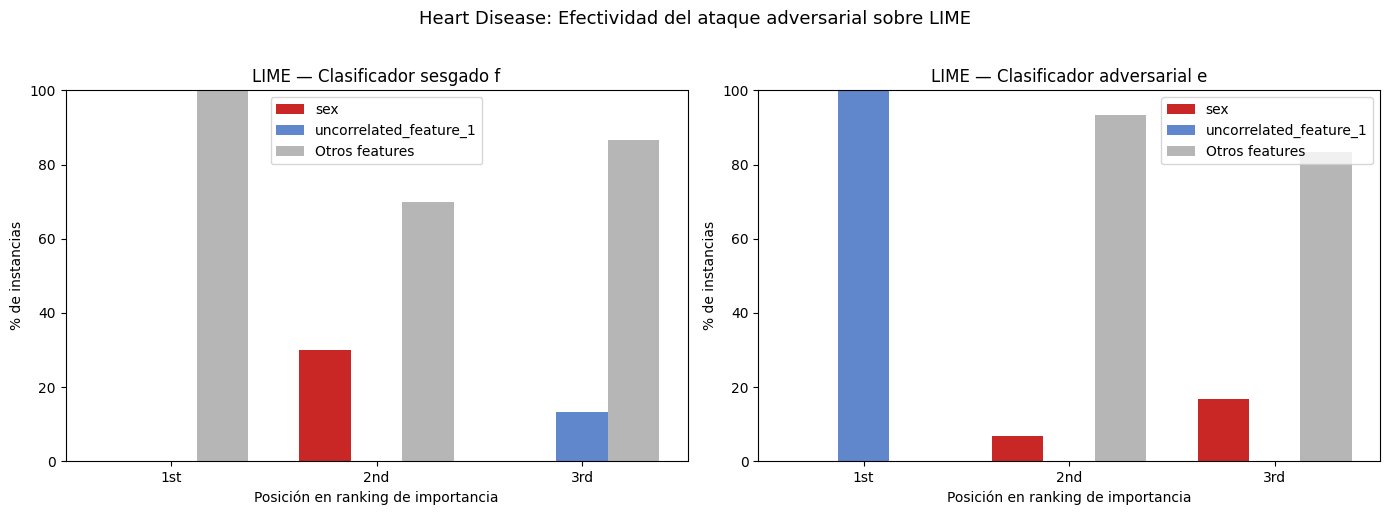

In [15]:
# Visualización — replica estilo Figura 2 del paper
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ranks = ['1st', '2nd', '3rd']
colors = {'sex': '#C00000', 'uncorrelated_feature_1': '#4472C4', 'others': '#A9A9A9'}

for ax, (stats, title) in zip(axes, [
    (stats_f, 'Clasificador sesgado f'),
    (stats_e, 'Clasificador adversarial e')
]):
    x = np.arange(3)
    width = 0.25
    for i, (feat, color) in enumerate(colors.items()):
        label = feat if feat != 'others' else 'Otros features'
        ax.bar(x + i * width, stats[feat], width, label=label, color=color, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(ranks)
    ax.set_xlabel('Posición en ranking de importancia')
    ax.set_ylabel('% de instancias')
    ax.set_title(f'LIME — {title}')
    ax.legend()
    ax.set_ylim(0, 100)

plt.suptitle('Heart Disease: Efectividad del ataque adversarial sobre LIME', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Evaluación del ataque sobre SHAP

In [19]:
import shap

# Background distribution: kmeans con 10 clusters (igual que el paper)
background = shap.kmeans(X_train_ext, 10)

# KernelSHAP explainer
shap_explainer_f = shap.KernelExplainer(
    lambda x: np.column_stack([1 - f_biased(x), f_biased(x)]),
    background
)
shap_explainer_e = shap.KernelExplainer(e_clf.predict_proba, background)

# Calcular SHAP values (subset para velocidad)
X_shap_test = X_test_ext[:30]

print("Calculando SHAP values para clasificador sesgado f...")
shap_values_f = shap_explainer_f.shap_values(X_shap_test, nsamples=200)
print("✓ Completado")

print("Calculando SHAP values para clasificador adversarial e...")
shap_values_e = shap_explainer_e.shap_values(X_shap_test, nsamples=200)
print("✓ Completado")

Calculando SHAP values para clasificador sesgado f...


100%|██████████| 30/30 [00:00<00:00, 269.70it/s]


✓ Completado
Calculando SHAP values para clasificador adversarial e...


100%|██████████| 30/30 [00:00<00:00, 98.98it/s]

✓ Completado


In [24]:
def get_shap_top3(shap_vals, class_idx=1):
    """Obtiene top-3 features por instancia según SHAP."""
    # Manejar formato 3D: (n_instances, n_features, n_classes)
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        vals = shap_vals[:, :, class_idx]  # → (30, 14)
    elif isinstance(shap_vals, list):
        vals = shap_vals[class_idx]
    else:
        vals = shap_vals

    top3_list = []
    for row in vals:  # row es ahora 1D (14,)
        top3_idx = np.argsort(np.abs(row))[::-1][:3]
        top3_list.append([feature_names_ext[int(i)] for i in top3_idx])
    return top3_list

def compute_shap_rank_stats(top3_list, sensitive_feat, uncorrelated_feat):
    n = len(top3_list)
    stats = {feat: [0, 0, 0] for feat in [sensitive_feat, uncorrelated_feat, 'others']}
    for top3 in top3_list:
        for rank, feat in enumerate(top3):
            if feat == sensitive_feat:
                stats[sensitive_feat][rank] += 1
            elif feat == uncorrelated_feat:
                stats[uncorrelated_feat][rank] += 1
            else:
                stats['others'][rank] += 1
    for feat in stats:
        stats[feat] = [v / n * 100 for v in stats[feat]]
    return stats

top3_f_shap = get_shap_top3(shap_values_f)
top3_e_shap = get_shap_top3(shap_values_e)

shap_stats_f = compute_shap_rank_stats(top3_f_shap, 'sex', 'uncorrelated_feature_1')
shap_stats_e = compute_shap_rank_stats(top3_e_shap, 'sex', 'uncorrelated_feature_1')

print("SHAP — Clasificador sesgado f:")
for feat, ranks in shap_stats_f.items():
    print(f"  {feat}: rank1={ranks[0]:.1f}%, rank2={ranks[1]:.1f}%, rank3={ranks[2]:.1f}%")

print("\nSHAP — Clasificador adversarial e:")
for feat, ranks in shap_stats_e.items():
    print(f"  {feat}: rank1={ranks[0]:.1f}%, rank2={ranks[1]:.1f}%, rank3={ranks[2]:.1f}%")

SHAP — Clasificador sesgado f:
  sex: rank1=100.0%, rank2=0.0%, rank3=0.0%
  uncorrelated_feature_1: rank1=0.0%, rank2=100.0%, rank3=0.0%
  others: rank1=0.0%, rank2=0.0%, rank3=100.0%

SHAP — Clasificador adversarial e:
  sex: rank1=100.0%, rank2=0.0%, rank3=0.0%
  uncorrelated_feature_1: rank1=0.0%, rank2=100.0%, rank3=0.0%
  others: rank1=0.0%, rank2=0.0%, rank3=100.0%


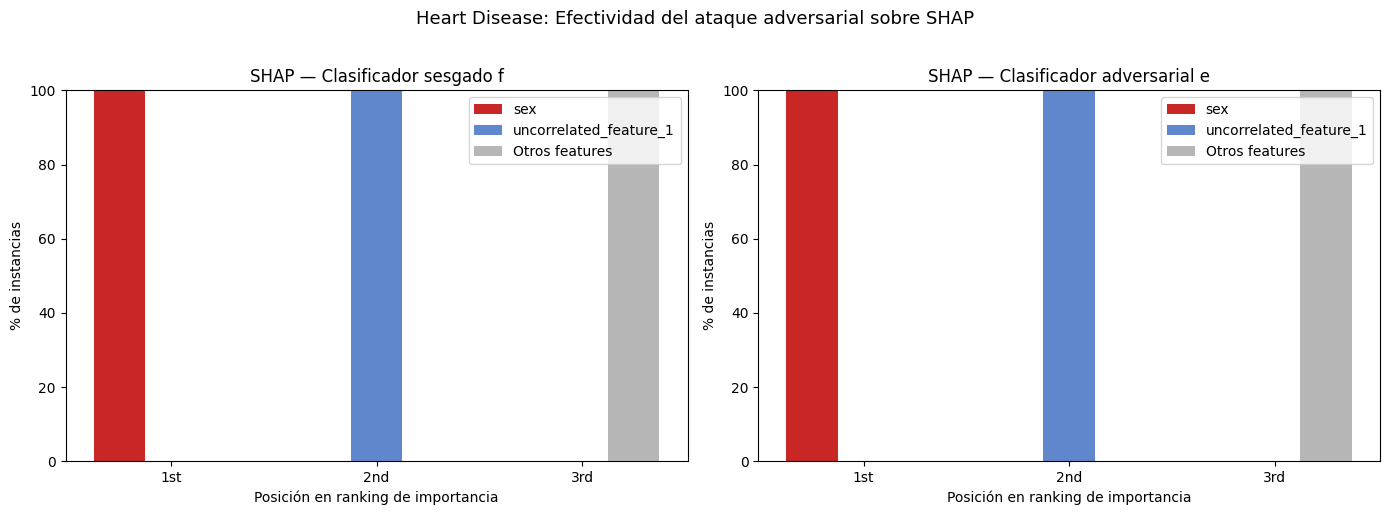

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (stats, title) in zip(axes, [
    (shap_stats_f, 'Clasificador sesgado f'),
    (shap_stats_e, 'Clasificador adversarial e')
]):
    x = np.arange(3)  # <-- esto faltaba, x debe ser índice numérico
    width = 0.25
    for i, (feat, color) in enumerate(colors.items()):
        label = feat if feat != 'others' else 'Otros features'
        ax.bar(x + i * width, stats[feat], width, label=label, color=color, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(['1st', '2nd', '3rd'])  # <-- etiquetas explícitas
    ax.set_xlabel('Posición en ranking de importancia')
    ax.set_ylabel('% de instancias')
    ax.set_title(f'SHAP — {title}')
    ax.legend()
    ax.set_ylim(0, 100)

plt.suptitle('Heart Disease: Efectividad del ataque adversarial sobre SHAP', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Análisis de ejemplo individual

Equivalente a la Tabla 2 y Figura 6 del paper: ver cómo cambian las explicaciones para un paciente concreto.

In [26]:
# Seleccionar un paciente de test (male, para que f lo clasifique como enfermo)
male_idx = np.where(X_test[:, sensitive_idx] == 1)[0][0]
patient = X_test_ext[male_idx]

print("=== Paciente de ejemplo ===")
for name, val in zip(feature_names_ext, patient):
    print(f"  {name}: {val:.3f}")
print(f"\nPredicción de f (sesgado): {f_biased(patient.reshape(1,-1))[0]}")
print(f"Predicción de e (adversarial): {e_clf.predict(patient.reshape(1,-1))[0]}")

=== Paciente de ejemplo ===
  age: 41.000
  sex: 1.000
  cp: 2.000
  trestbps: 120.000
  chol: 157.000
  fbs: 0.000
  restecg: 0.000
  thalach: 182.000
  exang: 0.000
  oldpeak: 0.000
  slope: 1.000
  ca: 0.000
  thal: 3.000
  uncorrelated_feature_1: 1.000

Predicción de f (sesgado): 1
Predicción de e (adversarial): 1


In [27]:
# LIME: comparar explicación antes y después del ataque
exp_f = lime_explainer.explain_instance(
    patient,
    lambda x: np.column_stack([1 - f_biased(x), f_biased(x)]),
    num_features=5
)

exp_e = lime_explainer.explain_instance(
    patient,
    e_clf.predict_proba,
    num_features=5
)

# Tabla comparativa
print("\n=== Explicación LIME: Clasificador SESGADO f ===")
for feat, weight in sorted(exp_f.as_list(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat[:40]:40s} → {weight:+.4f}")

print("\n=== Explicación LIME: Clasificador ADVERSARIAL e ===")
for feat, weight in sorted(exp_e.as_list(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat[:40]:40s} → {weight:+.4f}")


=== Explicación LIME: Clasificador SESGADO f ===
  chol                                     → -0.0019
  age                                      → -0.0017
  thalach                                  → +0.0016
  cp                                       → -0.0014
  uncorrelated_feature_1                   → +0.0012

=== Explicación LIME: Clasificador ADVERSARIAL e ===
  uncorrelated_feature_1                   → +0.2298
  cp                                       → +0.0224
  ca                                       → -0.0154
  oldpeak                                  → -0.0123
  exang                                    → -0.0075


100%|██████████| 1/1 [00:00<00:00, 52.53it/s]


TypeError: only integer scalar arrays can be converted to a scalar index

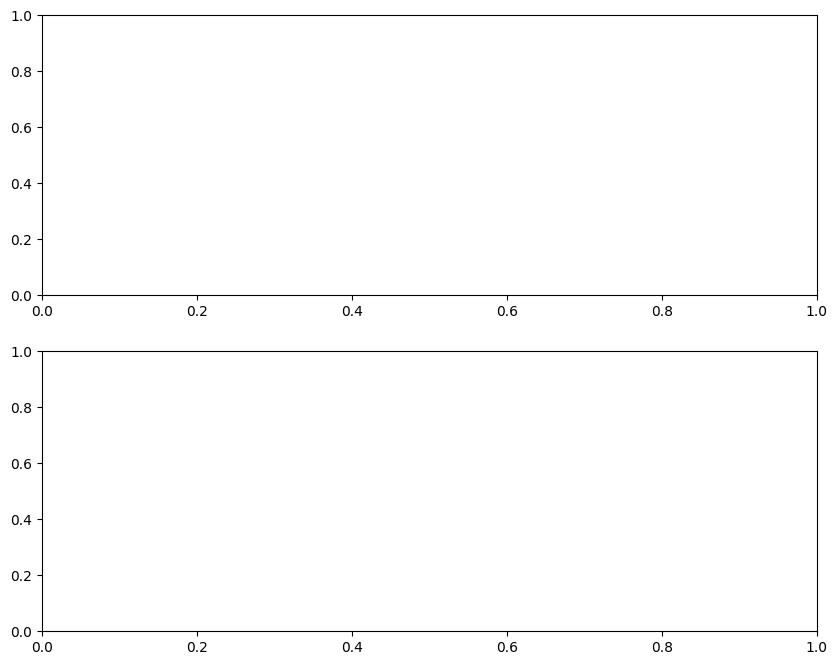

In [28]:
# Visualización SHAP de instancia individual
shap_f_single = shap_explainer_f.shap_values(patient.reshape(1, -1), nsamples=200)
shap_e_single = shap_explainer_e.shap_values(patient.reshape(1, -1), nsamples=200)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, (vals, title) in zip(axes, [
    (shap_f_single, 'Clasificador sesgado f'),
    (shap_e_single, 'Clasificador adversarial e')
]):
    if isinstance(vals, list):
        v = vals[1][0]
    else:
        v = vals[0]
    sorted_idx = np.argsort(np.abs(v))[::-1][:8]
    ax.barh(
        [feature_names_ext[i] for i in sorted_idx],
        v[sorted_idx],
        color=['#C00000' if x > 0 else '#4472C4' for x in v[sorted_idx]]
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'SHAP values — {title}')
    ax.set_xlabel('SHAP value')

plt.suptitle('Comparación SHAP: paciente individual (Heart Disease)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Resumen de resultados

Tabla resumen equivalente a los resultados del paper.

In [29]:
print("="*60)
print("RESUMEN DEL EXPERIMENTO — Heart Disease Dataset")
print("="*60)
print(f"\nDataset: {X.shape[0]} instancias, {X.shape[1]} features")
print(f"Atributo sensible: sex (0=F, 1=M)")
print(f"OOD Classifier F1: {f1:.4f}")
print(f"Fidelidad e→f: {fidelity:.4f}")

print("\n--- LIME ---")
sex_rank1_f = stats_f['sex'][0]
sex_rank1_e = stats_e['sex'][0]
unc_rank1_e = stats_e['uncorrelated_feature_1'][0]
print(f"'sex' en rank 1 ANTES del ataque: {sex_rank1_f:.1f}%")
print(f"'sex' en rank 1 DESPUÉS del ataque: {sex_rank1_e:.1f}%")
print(f"'uncorrelated_feature_1' en rank 1 tras ataque: {unc_rank1_e:.1f}%")

print("\n--- SHAP ---")
sex_rank1_f_shap = shap_stats_f['sex'][0]
sex_rank1_e_shap = shap_stats_e['sex'][0]
unc_rank1_e_shap = shap_stats_e['uncorrelated_feature_1'][0]
print(f"'sex' en rank 1 ANTES del ataque: {sex_rank1_f_shap:.1f}%")
print(f"'sex' en rank 1 DESPUÉS del ataque: {sex_rank1_e_shap:.1f}%")
print(f"'uncorrelated_feature_1' en rank 1 tras ataque: {unc_rank1_e_shap:.1f}%")
print("="*60)
print("\n→ Próximos pasos: variar el OOD classifier, probar 2 uncorrelated")
print("  features, e implementar defensas basadas en perturbaciones")
print("  más realistas (respetando la distribución del dataset).")

RESUMEN DEL EXPERIMENTO — Heart Disease Dataset

Dataset: 297 instancias, 13 features
Atributo sensible: sex (0=F, 1=M)
OOD Classifier F1: 1.0000
Fidelidad e→f: 1.0000

--- LIME ---
'sex' en rank 1 ANTES del ataque: 0.0%
'sex' en rank 1 DESPUÉS del ataque: 0.0%
'uncorrelated_feature_1' en rank 1 tras ataque: 100.0%

--- SHAP ---
'sex' en rank 1 ANTES del ataque: 100.0%
'sex' en rank 1 DESPUÉS del ataque: 100.0%
'uncorrelated_feature_1' en rank 1 tras ataque: 0.0%

→ Próximos pasos: variar el OOD classifier, probar 2 uncorrelated
  features, e implementar defensas basadas en perturbaciones
  más realistas (respetando la distribución del dataset).


In [37]:
def generate_shap_perturbations(X_real, background_data, n_perturbations=None):
    """
    Perturbaciones estilo SHAP: reemplaza subconjuntos de features
    con valores del background distribution (kmeans centers).
    """
    if n_perturbations is None:
        n_perturbations = len(X_real)
    
    perturbed = []
    for _ in range(n_perturbations):
        # Seleccionar instancia base aleatoria
        base = X_real[np.random.randint(len(X_real))].copy()
        # Seleccionar background aleatorio
        bg = background_data[np.random.randint(len(background_data))]
        # Máscara aleatoria: qué features se reemplazan
        mask = np.random.randint(0, 2, size=base.shape[0]).astype(bool)
        base[mask] = bg[mask]
        perturbed.append(base)
    
    return np.array(perturbed)

# Background centers del kmeans ya calculado
background_centers = background.data  # los centros del kmeans de SHAP

# Generar perturbaciones estilo SHAP
X_perturbed_shap = generate_shap_perturbations(X_train_ext, background_centers)

# Nuevo dataset OOD para SHAP
X_ood_shap = np.vstack([X_train_ext, X_perturbed_shap])
y_ood_shap = np.array([0] * len(X_train_ext) + [1] * len(X_perturbed_shap))

# Entrenar OOD classifier específico para SHAP
ood_clf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
ood_clf_shap.fit(X_ood_shap, y_ood_shap)

f1_shap = f1_score(y_ood_shap, ood_clf_shap.predict(X_ood_shap))
print(f"OOD Classifier SHAP-specific F1: {f1_shap:.4f}")

# Nuevo clasificador adversarial para SHAP
e_clf_shap = AdversarialClassifier(ood_clf_shap, f_biased)

# Recalcular SHAP values con el nuevo e
shap_explainer_e_v2 = shap.KernelExplainer(e_clf_shap.predict_proba, background)
shap_values_e_v2 = shap_explainer_e_v2.shap_values(X_shap_test, nsamples=200)

OOD Classifier SHAP-specific F1: 1.0000


100%|██████████| 30/30 [00:00<00:00, 72.23it/s]


In [34]:
import shap

# Background distribution: kmeans con 10 clusters (igual que el paper)
background = shap.kmeans(X_train_ext, 10)

# KernelSHAP explainer
shap_explainer_f = shap.KernelExplainer(
    lambda x: np.column_stack([1 - f_biased(x), f_biased(x)]),
    background
)
shap_explainer_e = shap.KernelExplainer(e_clf.predict_proba, background)

# Calcular SHAP values (subset para velocidad)
X_shap_test = X_test_ext[:30]

print("Calculando SHAP values para clasificador sesgado f...")
shap_values_f = shap_explainer_f.shap_values(X_shap_test, nsamples=200)
print("✓ Completado")

print("Calculando SHAP values para clasificador adversarial e...")
shap_values_e = shap_explainer_e.shap_values(X_shap_test, nsamples=200)
print("✓ Completado")

Calculando SHAP values para clasificador sesgado f...


100%|██████████| 30/30 [00:00<00:00, 392.23it/s]


✓ Completado
Calculando SHAP values para clasificador adversarial e...


100%|██████████| 30/30 [00:00<00:00, 95.60it/s]

✓ Completado


In [38]:
def get_shap_top3(shap_vals, class_idx=1):
    """Obtiene top-3 features por instancia según SHAP."""
    # Manejar formato 3D: (n_instances, n_features, n_classes)
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        vals = shap_vals[:, :, class_idx]  # → (30, 14)
    elif isinstance(shap_vals, list):
        vals = shap_vals[class_idx]
    else:
        vals = shap_vals

    top3_list = []
    for row in vals:  # row es ahora 1D (14,)
        top3_idx = np.argsort(np.abs(row))[::-1][:3]
        top3_list.append([feature_names_ext[int(i)] for i in top3_idx])
    return top3_list

def compute_shap_rank_stats(top3_list, sensitive_feat, uncorrelated_feat):
    n = len(top3_list)
    stats = {feat: [0, 0, 0] for feat in [sensitive_feat, uncorrelated_feat, 'others']}
    for top3 in top3_list:
        for rank, feat in enumerate(top3):
            if feat == sensitive_feat:
                stats[sensitive_feat][rank] += 1
            elif feat == uncorrelated_feat:
                stats[uncorrelated_feat][rank] += 1
            else:
                stats['others'][rank] += 1
    for feat in stats:
        stats[feat] = [v / n * 100 for v in stats[feat]]
    return stats

top3_f_shap = get_shap_top3(shap_values_f)
top3_e_shap = get_shap_top3(shap_values_e_v2)

shap_stats_f = compute_shap_rank_stats(top3_f_shap, 'sex', 'uncorrelated_feature_1')
shap_stats_e = compute_shap_rank_stats(top3_e_shap, 'sex', 'uncorrelated_feature_1')

print("SHAP — Clasificador sesgado f:")
for feat, ranks in shap_stats_f.items():
    print(f"  {feat}: rank1={ranks[0]:.1f}%, rank2={ranks[1]:.1f}%, rank3={ranks[2]:.1f}%")

print("\nSHAP — Clasificador adversarial e:")
for feat, ranks in shap_stats_e.items():
    print(f"  {feat}: rank1={ranks[0]:.1f}%, rank2={ranks[1]:.1f}%, rank3={ranks[2]:.1f}%")

SHAP — Clasificador sesgado f:
  sex: rank1=100.0%, rank2=0.0%, rank3=0.0%
  uncorrelated_feature_1: rank1=0.0%, rank2=100.0%, rank3=0.0%
  others: rank1=0.0%, rank2=0.0%, rank3=100.0%

SHAP — Clasificador adversarial e:
  sex: rank1=23.3%, rank2=6.7%, rank3=20.0%
  uncorrelated_feature_1: rank1=56.7%, rank2=36.7%, rank3=6.7%
  others: rank1=20.0%, rank2=56.7%, rank3=73.3%


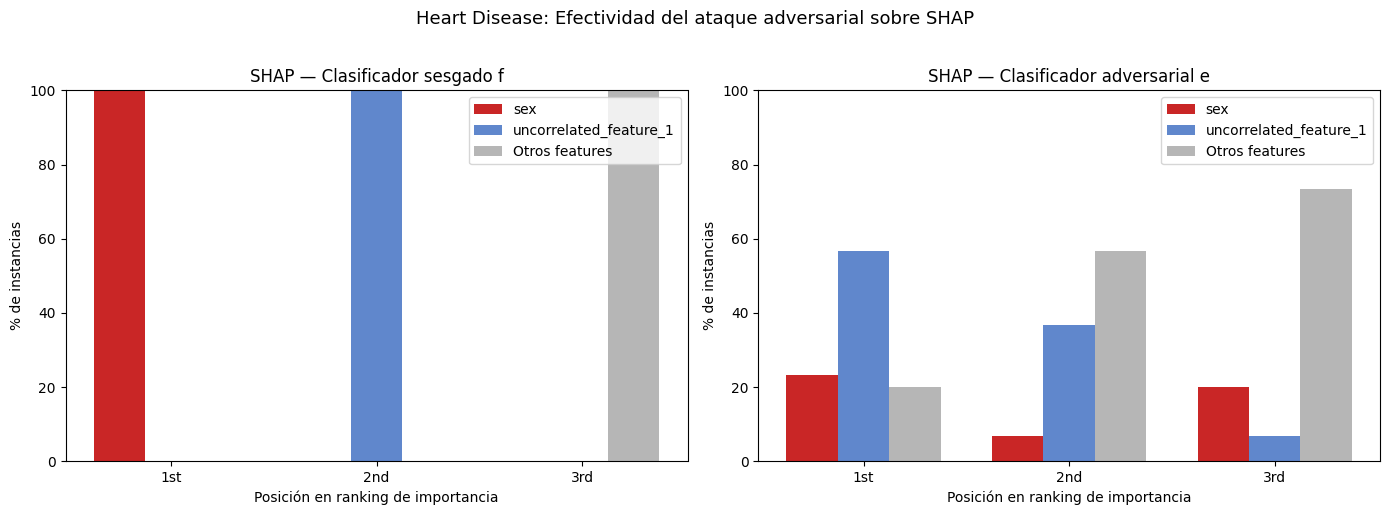

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (stats, title) in zip(axes, [
    (shap_stats_f, 'Clasificador sesgado f'),
    (shap_stats_e, 'Clasificador adversarial e')
]):
    x = np.arange(3)  # <-- esto faltaba, x debe ser índice numérico
    width = 0.25
    for i, (feat, color) in enumerate(colors.items()):
        label = feat if feat != 'others' else 'Otros features'
        ax.bar(x + i * width, stats[feat], width, label=label, color=color, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(['1st', '2nd', '3rd'])  # <-- etiquetas explícitas
    ax.set_xlabel('Posición en ranking de importancia')
    ax.set_ylabel('% de instancias')
    ax.set_title(f'SHAP — {title}')
    ax.legend()
    ax.set_ylim(0, 100)

plt.suptitle('Heart Disease: Efectividad del ataque adversarial sobre SHAP', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()